In [18]:
import os
import httpx
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv(override=True)

BASE_URL = os.getenv("OPENAI_BASE_URL")
API_KEY = os.getenv("OPENAI_API_KEY")
MODEL = os.getenv("OPENAI_MODEL")

transport = httpx.HTTPTransport(verify=False)
http_client = httpx.Client(transport=transport)

llm = ChatOpenAI(
    base_url = BASE_URL,
    api_key = API_KEY,
    model = MODEL,
    http_client = http_client,
    streaming = False
)

In [19]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]
    name: str
    birthday: str

graph_builder = StateGraph(State)

In [20]:
from langchain_tavily import TavilySearch
from langchain_core.messages import ToolMessage
from langchain_core.tools import tool, InjectedToolCallId
from langgraph.types import Command, interrupt

@tool
def human_assistance(
    name: str, birthday: str, tool_call_id: Annotated[str, InjectedToolCallId]
):
    """This is for human interrupt."""
    human_response = interrupt(
        {
            "question": "Is this correct?",
            "name": name,
            "birthday": birthday,
        },
    )

    if human_response.get("correct", "").lower().startswith("y"):
        verified_name = name
        verified_birthday = birthday
        response = "Correct"
    else:
        verified_name = human_response.get("name", name)
        verified_birthday = human_response.get("birthday", birthday)
        response = f"Made a correction: {human_response}"
    
    state_update = {
        "name": verified_name,
        "birthday": verified_birthday,
        "messages": [ToolMessage(response, tool_call_id=tool_call_id)],
    }
    return Command(update=state_update)

tool = TavilySearch(max_results=3)
tools = [tool, human_assistance]
llm_with_tools = llm.bind_tools(tools)


In [21]:
from langgraph.prebuilt import ToolNode, tools_condition

def chatbot(state:State):
    message = llm_with_tools.invoke(state["messages"])
    assert(len(message.tool_calls) <= 1)
    return {"messages": [message]}

graph_builder.add_node("chatbot", chatbot)
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")


In [22]:
from langgraph.checkpoint.memory import InMemorySaver

memory = InMemorySaver()
graph = graph_builder.compile(checkpointer=memory)

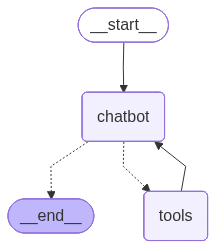

In [23]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [24]:
config = {"configurable": {"thread_id": "1"}}
events = graph.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "I'm learning LangGraph. "
                    "Could you do some research on it for me?"
                ),
            },
        ],
    },
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I'm learning LangGraph. Could you do some research on it for me?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (01998117ecf8842aeeb3dcf58fd440eb)
 Call ID: 01998117ecf8842aeeb3dcf58fd440eb
  Args:
    query: LangGraph
    search_depth: advanced
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "LangGraph", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.ibm.com/think/topics/langgraph", "title": "What is LangGraph? - IBM", "content": "LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient ma

In [25]:
events = graph.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "Ya that's helpful. Maybe I'll "
                    'build an autonomous agent with it!'
                ),
            },
        ],
    },
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

Ya that's helpful. Maybe I'll build an autonomous agent with it!
================================== Ai Message ==================================

That sounds exciting! Building an autonomous agent with **LangGraph** could be a great way to explore advanced AI workflows. Here’s a more focused breakdown of how LangGraph might help:

---

### **Key Concepts for Autonomous Agents in LangGraph**
1. **State Management**:  
   Autonomous agents often need to track internal states (e.g., goals, memory, or context). LangGraph’s stateful design allows agents to retain and update state across interactions, enabling behaviors like decision-making based on past actions.

2. **Cyclic Workflows**:  
   Agents may require loops or iterative processes (e.g., refining responses, re-evaluating goals). LangGraph’s graph-based architecture supports cyclic paths, letting agents "think" or adjust their behavior dynamically.

3

In [26]:
to_replay = None
for state in graph.get_state_history(config):
    print("Num Messages: ", len(state.values["messages"]), "Next: ", state.next)
    print("-" * 80)
    if len(state.values["messages"]) == 6:
        to_replay = state

Num Messages:  6 Next:  ()
--------------------------------------------------------------------------------
Num Messages:  5 Next:  ('chatbot',)
--------------------------------------------------------------------------------
Num Messages:  4 Next:  ('__start__',)
--------------------------------------------------------------------------------
Num Messages:  4 Next:  ()
--------------------------------------------------------------------------------
Num Messages:  3 Next:  ('chatbot',)
--------------------------------------------------------------------------------
Num Messages:  2 Next:  ('tools',)
--------------------------------------------------------------------------------
Num Messages:  1 Next:  ('chatbot',)
--------------------------------------------------------------------------------
Num Messages:  0 Next:  ('__start__',)
--------------------------------------------------------------------------------


In [27]:
print(to_replay.next)
print(to_replay.config)

()
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f09a159-66aa-6292-8006-a2c6d7692a67'}}


In [28]:
for event in graph.stream(None, to_replay.config, stream_mode="values"):
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================

That sounds exciting! Building an autonomous agent with **LangGraph** could be a great way to explore advanced AI workflows. Here’s a more focused breakdown of how LangGraph might help:

---

### **Key Concepts for Autonomous Agents in LangGraph**
1. **State Management**:  
   Autonomous agents often need to track internal states (e.g., goals, memory, or context). LangGraph’s stateful design allows agents to retain and update state across interactions, enabling behaviors like decision-making based on past actions.

2. **Cyclic Workflows**:  
   Agents may require loops or iterative processes (e.g., refining responses, re-evaluating goals). LangGraph’s graph-based architecture supports cyclic paths, letting agents "think" or adjust their behavior dynamically.

3. **Multi-Agent Coordination**:  
   If your agent interacts with other agents or tools, LangGraph’s explicit coordination model ensures smooth com